## 0. Импорты и настройки

In [1]:
import os
import gzip
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.linear_model import Ridge
import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 4.5)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DAY, WEEK = 24, 24 * 7
HORIZON = WEEK          # прогнозируем на 24*7 = 168 часов вперёд
TEST_HOURS = 2 * WEEK   # отложенная выборка — последние 2 недели
VAL_HOURS = 2 * WEEK    # валидация для отбора моделей — 2 недели перед тестом

print("pandas", pd.__version__, "| numpy", np.__version__, "| lightgbm", lgb.__version__)

pandas 3.0.3 | numpy 2.5.0 | lightgbm 4.7.0


## 1. Загрузка данных

In [2]:
CSV = "Metro_Interstate_Traffic_Volume.csv"
URL = "https://archive.ics.uci.edu/static/public/492/metro+interstate+traffic+volume.zip"

if not os.path.exists(CSV):
    import io, urllib.request, zipfile
    print("Скачиваем данные с UCI...")
    blob = urllib.request.urlopen(URL, timeout=120).read()
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        name = z.namelist()[0]           # Metro_Interstate_Traffic_Volume.csv.gz
        with z.open(name) as src, gzip.open(src, "rb") as gz, open(CSV, "wb") as dst:
            shutil.copyfileobj(gz, dst)
    print("Готово.")

raw = pd.read_csv(CSV, parse_dates=["date_time"])
print("Размер исходной таблицы:", raw.shape)
raw.head()

Размер исходной таблицы: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 4.1 MB


### 1.1. Оставляем нужные столбцы

In [4]:
#нужны только четыре столбца: `date_time`, `traffic_volume` (целевая переменная),
#`holiday` (праздник) и `temp` (температура в Кельвинах).
df = raw[["date_time", "holiday", "temp", "traffic_volume"]].copy()
print("Пропуски (NaN) по столбцам:")
print(df.isna().sum())
print("\nПериод наблюдений:", df["date_time"].min(), "—", df["date_time"].max())
df.describe(include="all").T

Пропуски (NaN) по столбцам:
date_time             0
holiday           48143
temp                  0
traffic_volume        0
dtype: int64

Период наблюдений: 2012-10-02 09:00:00 — 2018-09-30 23:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date_time,48204,NaN,NaN,NaN,2016-01-05 10:46:16.773711,2012-10-02 09:00:00,2014-02-06 11:45:00,2016-06-11 03:30:00,2017-08-11 06:00:00,2018-09-30 23:00:00,NaN
holiday,61,11,Labor Day,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp,48204.0,NaN,NaN,NaN,281.20587,0.0,272.16,282.45,291.806,310.07,13.338232
traffic_volume,48204.0,NaN,NaN,NaN,3259.818355,0.0,1193.0,3380.0,4933.0,7280.0,1986.86067


`holiday` заполнен не для всех строк праздничного дня, а только для строки, соответствующей **началу суток**,
поэтому непустых значений всего несколько десятков. Ниже это исправим, «растянув» признак на все часы праздничного дня.

`temp` измеряется в Кельвинах, и минимум `0 K` — очевидная аномалия (абсолютный ноль), это пропуски-заглушки.

In [5]:
print("Уникальные значения holiday (без NaN):")
print(df["holiday"].dropna().value_counts())
print("\nЧисло строк с temp = 0 K:", int((df["temp"] == 0).sum()))
print("Даты аномальной температуры:")
print(df.loc[df["temp"] == 0, "date_time"].dt.date.value_counts())

Уникальные значения holiday (без NaN):
holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

Число строк с temp = 0 K: 10
Даты аномальной температуры:
date_time
2014-02-02    6
2014-01-31    4
Name: count, dtype: int64


### 1.2. Дубликаты

In [6]:
dup_full = df.duplicated().sum()
dup_time = df["date_time"].duplicated().sum()
print(f"Полных дубликатов строк: {dup_full}")
print(f"Дубликатов по date_time: {dup_time} ({dup_time / len(df):.1%} наблюдений)")

example = df["date_time"].value_counts().idxmax()
print(f"\nПример: метка {example} встречается {df['date_time'].value_counts().max()} раз(а)")
raw.loc[raw["date_time"] == example,
        ["date_time", "temp", "weather_main", "weather_description", "traffic_volume"]]

Полных дубликатов строк: 7551
Дубликатов по date_time: 7629 (15.8% наблюдений)

Пример: метка 2013-04-18 22:00:00 встречается 6 раз(а)


,date_time,temp,weather_main,weather_description,traffic_volume
5249,2013-04-18 22:00:00,274.79,Mist,mist,1532
5250,2013-04-18 22:00:00,274.79,Drizzle,light intensity drizzle,1532
5251,2013-04-18 22:00:00,274.79,Rain,light rain,1532
5252,2013-04-18 22:00:00,274.79,Rain,moderate rain,1532
5253,2013-04-18 22:00:00,274.79,Snow,heavy snow,1532
5254,2013-04-18 22:00:00,274.79,Snow,snow,1532


Видно, что дубли по времени порождены столбцами погоды: для одного часа в исходных данных заведено несколько строк
с разными погодными явлениями (дождь + туман и т.п.), а `traffic_volume` при этом одинаков.
Так как погодные столбцы нам не нужны, **дубликаты по `date_time` просто удаляем**, оставляя первую строку.

In [7]:
df = df.sort_values("date_time").drop_duplicates(subset="date_time", keep="first")
df = df.set_index("date_time").sort_index()
print("После удаления дубликатов:", df.shape)
print("Дубликатов по индексу осталось:", int(df.index.duplicated().sum()))

После удаления дубликатов: (40575, 3)
Дубликатов по индексу осталось: 0


### 1.3. Равномерность временной сетки

Ряд должен быть почасовым. Смотрим на распределение шагов между соседними наблюдениями.

In [8]:
steps = df.index.to_series().diff().dropna()
print("Распределение шага между наблюдениями (топ-10):")
print(steps.value_counts().head(10))
print(f"\nДоля шагов ровно в 1 час: {(steps == pd.Timedelta('1h')).mean():.2%}")

print("\n10 самых больших разрывов в данных:")
gaps = steps.sort_values(ascending=False).head(10)
print(pd.DataFrame({"конец разрыва": gaps.index, "длительность": gaps.values}).to_string(index=False))

Распределение шага между наблюдениями (топ-10):
date_time
0 days 01:00:00    37986
0 days 02:00:00     2192
0 days 03:00:00      201
0 days 04:00:00       59
0 days 05:00:00       33
0 days 06:00:00       17
0 days 08:00:00       13
0 days 10:00:00       13
0 days 09:00:00       12
0 days 07:00:00       10
Name: count, dtype: int64

Доля шагов ровно в 1 час: 93.62%

10 самых больших разрывов в данных:
      конец разрыва      длительность
2015-06-11 20:00:00 307 days 19:00:00
2013-11-06 04:00:00  10 days 03:00:00
2015-06-19 18:00:00   4 days 22:00:00
2014-05-04 05:00:00   4 days 21:00:00
2015-10-27 08:00:00   3 days 21:00:00
2014-07-30 09:00:00   2 days 17:00:00
2013-09-01 23:00:00   1 days 23:00:00
2015-06-24 04:00:00   1 days 10:00:00
2014-08-03 11:00:00   1 days 09:00:00
2013-09-04 08:00:00   1 days 06:00:00


Равномерность действительно нарушена: помимо часового шага встречаются пропуски в несколько часов,
а также несколько очень крупных разрывов (самый большой — несколько месяцев в 2014–2015 гг.).

Выравниваем сетку через `pd.date_range(freq="h")` и заполняем пропуски **линейной интерполяцией**
(для временного ряда используем `method="time"`, что на равномерной сетке эквивалентно линейной).

In [9]:
full_index = pd.date_range(df.index.min(), df.index.max(), freq="h")
data = df.reindex(full_index)
data.index.name = "date_time"

n_missing = int(data["traffic_volume"].isna().sum())
print(f"Точек в полной почасовой сетке: {len(full_index)}")
print(f"Из них пропущено (нет наблюдения): {n_missing} ({n_missing / len(full_index):.1%})")

# аномальную температуру 0 K считаем пропуском
data.loc[data["temp"] == 0, "temp"] = np.nan

data["traffic_volume"] = data["traffic_volume"].interpolate(method="time")
data["temp"] = data["temp"].interpolate(method="time")

print("\nПропусков после интерполяции:", data[["traffic_volume", "temp"]].isna().sum().to_dict())
print("Уникальный шаг сетки:", data.index.to_series().diff().dropna().unique())

Точек в полной почасовой сетке: 52551
Из них пропущено (нет наблюдения): 11976 (22.8%)

Пропусков после интерполяции: {'traffic_volume': 0, 'temp': 0}
Уникальный шаг сетки: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]


### 1.4. Праздники и температура

* `holiday` растягиваем на все 24 часа праздничных суток и превращаем в бинарный флаг.
* Температуру переводим в градусы Цельсия — так удобнее интерпретировать.

In [10]:
holiday_days = pd.to_datetime(df.loc[df["holiday"].notna()].index.normalize().unique())


def holiday_flag(index):
    # флаг праздника для любого индекса, в том числе для будущих дат
    return index.normalize().isin(holiday_days).astype(int)


data["is_holiday"] = holiday_flag(data.index)
data["temp_c"] = data["temp"] - 273.15
data = data.drop(columns=["holiday", "temp"])

print("Праздничных дней в выборке:", len(holiday_days))
print("Праздничных часов:", int(data["is_holiday"].sum()))
print("\nТемпература, °C:")
print(data["temp_c"].describe().round(1).to_string())
data.head()

Праздничных дней в выборке: 53
Праздничных часов: 1272

Температура, °C:
count    52551.0
mean         9.4
std         12.4
min        -29.8
25%          0.4
50%         13.3
75%         18.6
max         36.9


,traffic_volume,is_holiday,temp_c
date_time,,,
2012-10-02 09:00:00,5545.0,0,15.13
2012-10-02 10:00:00,4516.0,0,16.21
2012-10-02 11:00:00,4767.0,0,16.43
2012-10-02 12:00:00,5026.0,0,16.98
2012-10-02 13:00:00,4918.0,0,17.99


### 1.5. Разведочные графики

Смотрим на ряд целиком и на его сезонные профили.

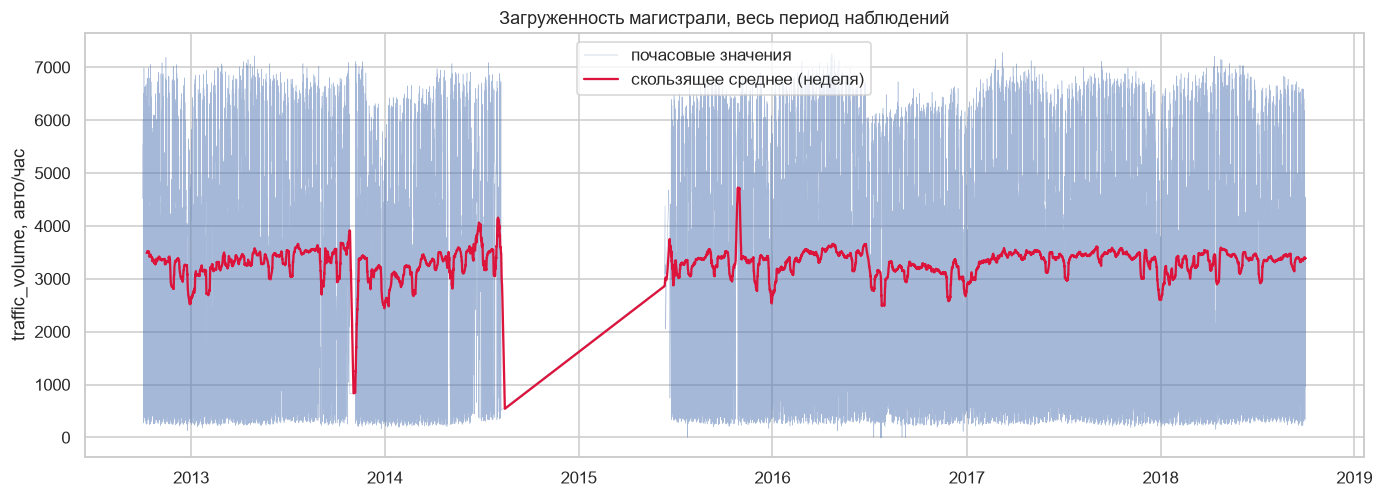

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(data.index, data["traffic_volume"], lw=0.3, alpha=0.5, label="почасовые значения")
ax.plot(data.index, data["traffic_volume"].rolling(WEEK).mean(), color="crimson", lw=1.5,
        label="скользящее среднее (неделя)")
ax.set_title("Загруженность магистрали, весь период наблюдений")
ax.set_ylabel("traffic_volume, авто/час")
ax.legend()
plt.show()

Тренда как такового нет — ряд стационарен по уровню, зато отчётливо видны периоды, заполненные
интерполяцией (ровные «полки» в 2014–2015 гг.), и сильная внутринедельная сезонность.

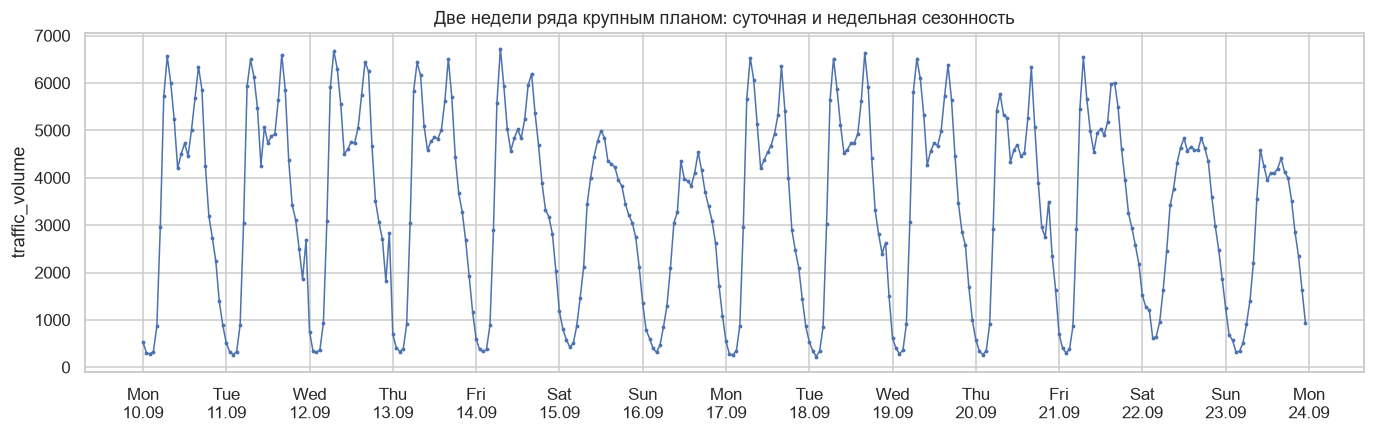

In [12]:
last_2w = data["traffic_volume"].iloc[-3 * WEEK:-WEEK]
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(last_2w.index, last_2w.values, marker=".", ms=3, lw=1)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d.%m"))
ax.set_title("Две недели ряда крупным планом: суточная и недельная сезонность")
ax.set_ylabel("traffic_volume")
plt.show()

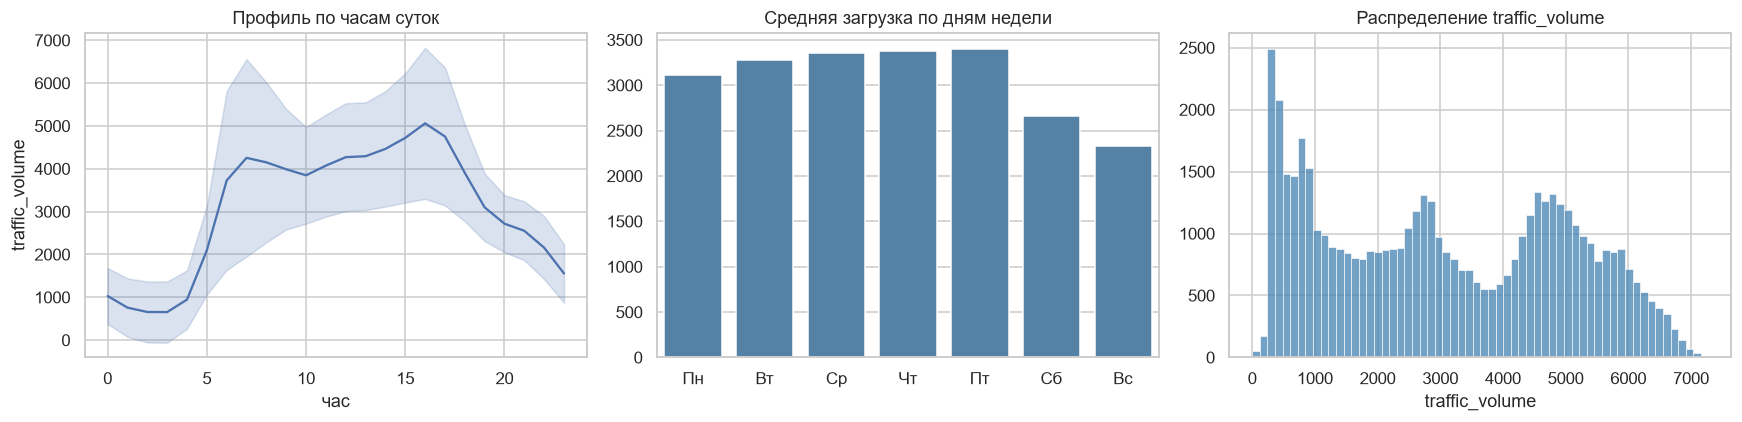

In [13]:
prof = data.copy()
prof["hour"] = prof.index.hour
prof["weekday"] = prof.index.weekday
WD = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.lineplot(data=prof, x="hour", y="traffic_volume", errorbar="sd", ax=axes[0])
axes[0].set_title("Профиль по часам суток")
axes[0].set_xlabel("час"); axes[0].set_ylabel("traffic_volume")

sns.barplot(data=prof, x="weekday", y="traffic_volume", errorbar=None, ax=axes[1], color="steelblue")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(WD)
axes[1].set_title("Средняя загрузка по дням недели")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

sns.histplot(prof["traffic_volume"], bins=60, ax=axes[2], color="steelblue")
axes[2].set_title("Распределение traffic_volume")
axes[2].set_xlabel("traffic_volume"); axes[2].set_ylabel("")
plt.tight_layout(); plt.show()

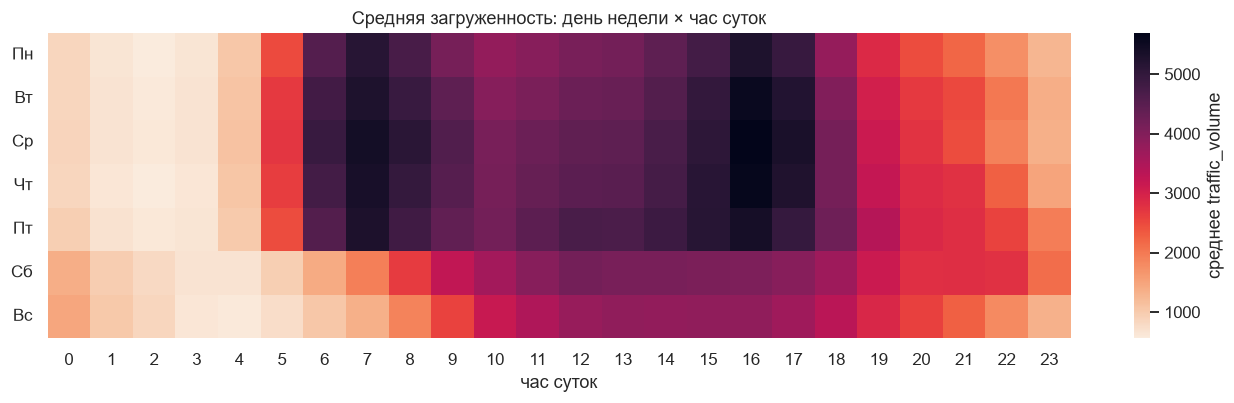

In [14]:
pivot = prof.pivot_table(index="weekday", columns="hour", values="traffic_volume", aggfunc="mean")
fig, ax = plt.subplots(figsize=(15, 3.6))
sns.heatmap(pivot, cmap="rocket_r", ax=ax, cbar_kws={"label": "среднее traffic_volume"})
ax.set_yticklabels(WD, rotation=0)
ax.set_title("Средняя загруженность: день недели × час суток")
ax.set_xlabel("час суток"); ax.set_ylabel("")
plt.show()

Будние дни: два пика — утренний (07–08) и вечерний (16–17), провал ночью.
В выходные пиков нет, профиль плоский с максимумом около полудня, а общий уровень заметно ниже.
Именно это и должна ловить модель.

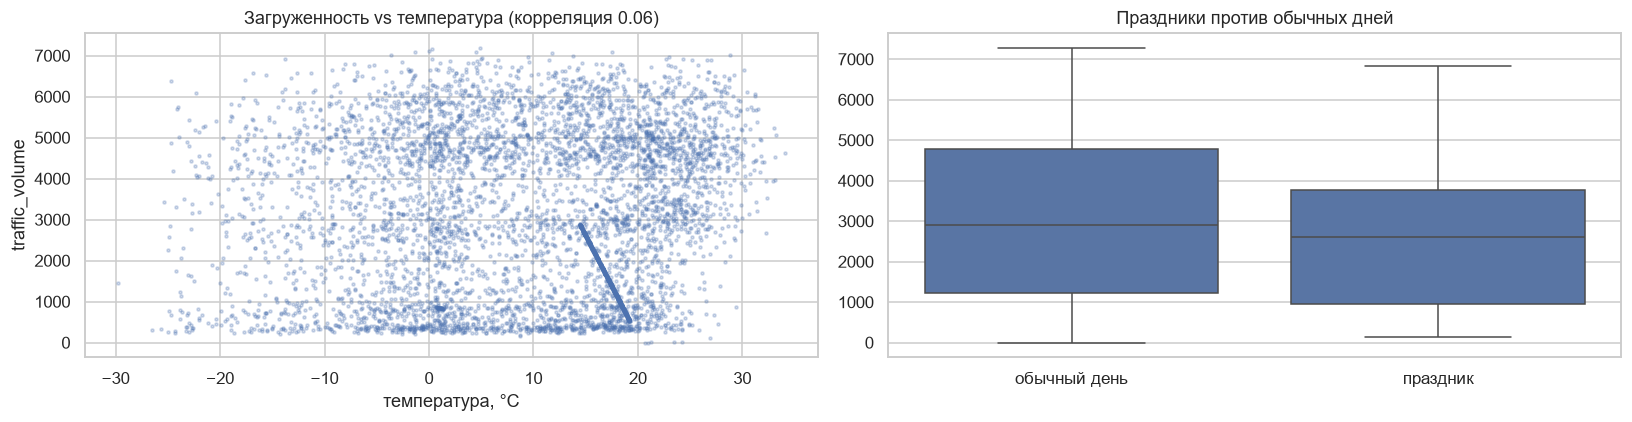

              mean  median  count
is_holiday                       
0           3084.0  2908.0  51279
1           2571.0  2598.0   1272


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sample = prof.sample(6000, random_state=RANDOM_STATE)
axes[0].scatter(sample["temp_c"], sample["traffic_volume"], s=4, alpha=0.25)
axes[0].set_title(f"Загруженность vs температура (корреляция {prof['temp_c'].corr(prof['traffic_volume']):.2f})")
axes[0].set_xlabel("температура, °C"); axes[0].set_ylabel("traffic_volume")

sns.boxplot(data=prof, x="is_holiday", y="traffic_volume", ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["обычный день", "праздник"])
axes[1].set_title("Праздники против обычных дней")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

print(prof.groupby("is_holiday")["traffic_volume"].agg(["mean", "median", "count"]).round(0))

Связь с температурой слабо-положительная (в мороз ездят меньше), а праздники дают заметное падение
среднего трафика — оба признака имеет смысл использовать в моделях.

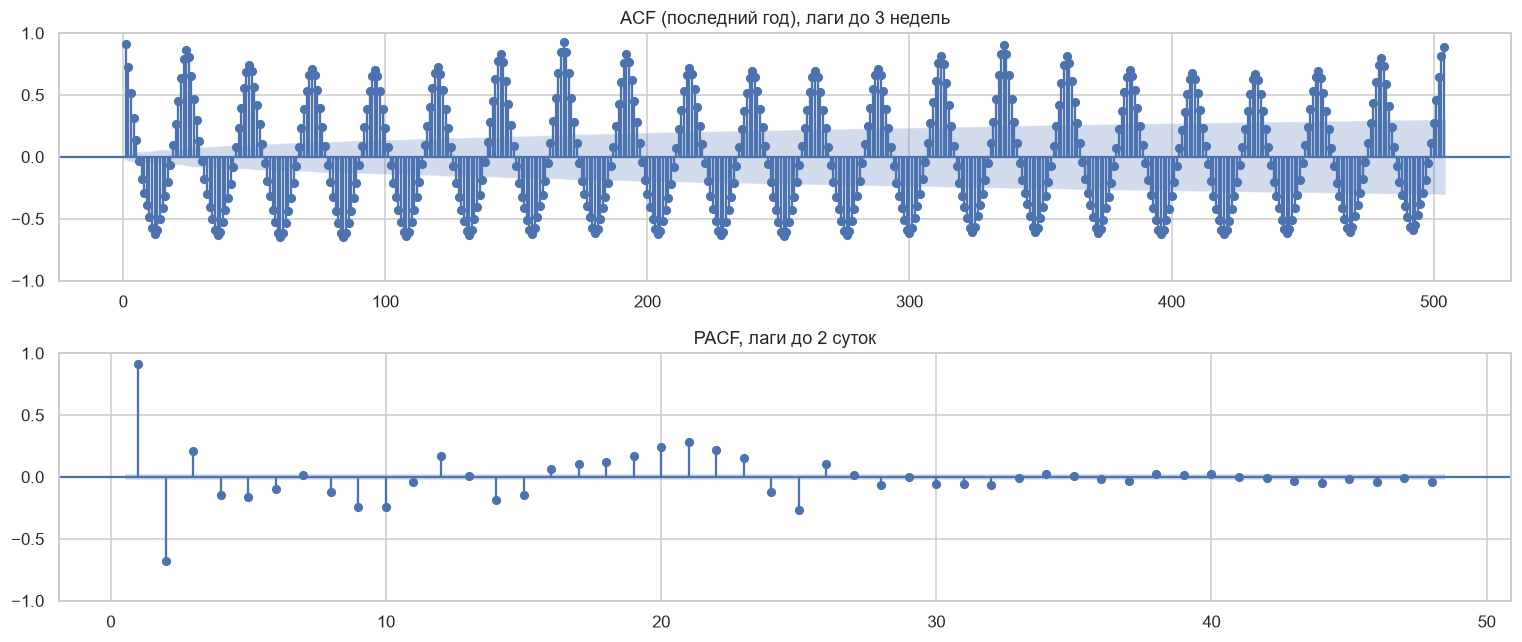

In [16]:
recent = data["traffic_volume"].iloc[-52 * WEEK:]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(recent, lags=3 * WEEK, ax=axes[0], zero=False)
axes[0].set_title("ACF (последний год), лаги до 3 недель")
plot_pacf(recent, lags=2 * DAY, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("PACF, лаги до 2 суток")
plt.tight_layout(); plt.show()

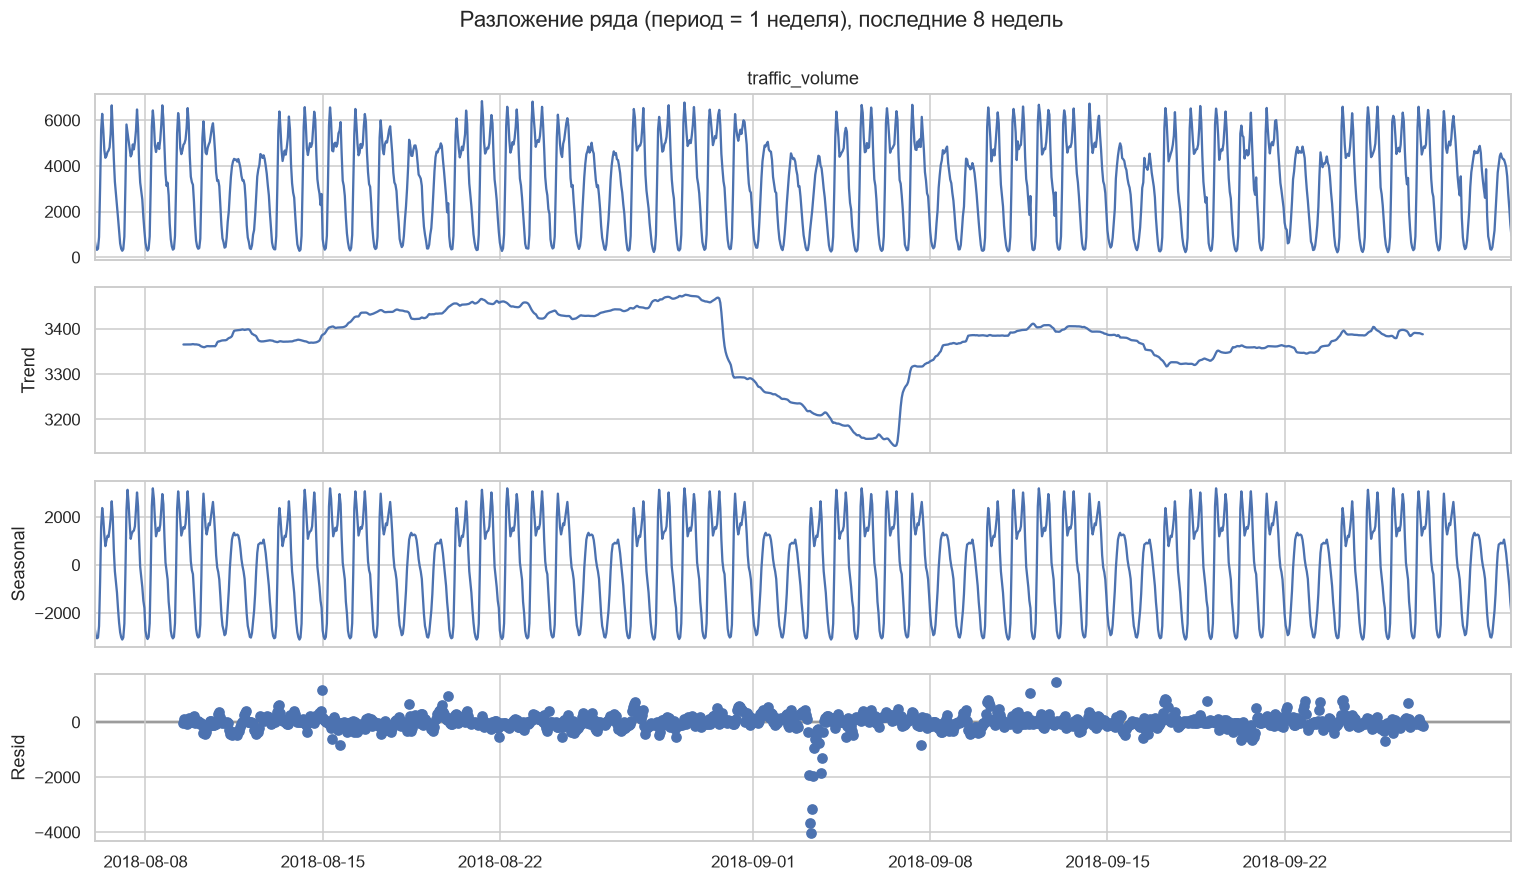

In [17]:
dec = seasonal_decompose(data["traffic_volume"].iloc[-8 * WEEK:], model="additive", period=WEEK)
fig = dec.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Разложение ряда (период = 1 неделя), последние 8 недель", y=1.0)
plt.tight_layout(); plt.show()

ACF показывает выраженные всплески на лагах, кратных 24 и 168 часам, — суточная и недельная сезонности
доминируют. Разложение подтверждает: сезонная компонента объясняет основную часть дисперсии,
тренд практически плоский.

**Итоги EDA**

* Исходно 48 204 строки, из них 7 629 — дубликаты по времени (порождены столбцами погоды), удалены.
* Сетка была неравномерной: только ~93% шагов равны часу; после выравнивания и интерполяции получаем непрерывный почасовой ряд.
* В `temp` есть аномалии 0 K — заменены интерполяцией.
* Ряд без тренда, с сильной суточной и недельной сезонностью; праздники и температура влияют на уровень.

## 2. Генерация дополнительных признаков

Из индекса делаем календарные признаки; для линейных моделей добавляем циклические
преобразования (sin/cos), а для бустинга — лаговые признаки.

Лаги берём **кратные неделе и не меньше 336 часов** (2 недели): при горизонте прогноза в 2 недели
такие значения известны на момент прогноза, поэтому подглядывания в будущее не происходит.

In [18]:
LAGS = [336, 504, 672, 840]  # 2, 3, 4, 5 недель назад


def calendar_features(index):
    # Календарные признаки из DatetimeIndex.
    X = pd.DataFrame(index=index)
    X["hour"] = index.hour
    X["weekday"] = index.weekday
    X["month"] = index.month
    X["dayofyear"] = index.dayofyear
    X["is_weekend"] = (index.weekday >= 5).astype(int)
    X["sin_hour"] = np.sin(2 * np.pi * index.hour / 24)
    X["cos_hour"] = np.cos(2 * np.pi * index.hour / 24)
    X["sin_wday"] = np.sin(2 * np.pi * index.weekday / 7)
    X["cos_wday"] = np.cos(2 * np.pi * index.weekday / 7)
    return X


feat = calendar_features(data.index)
feat["is_holiday"] = data["is_holiday"].values
feat["temp_c"] = data["temp_c"].values
for lag in LAGS:
    feat[f"lag_{lag}"] = data["traffic_volume"].shift(lag)
feat["lag_mean"] = feat[[f"lag_{l}" for l in LAGS]].mean(axis=1)
feat["traffic_volume"] = data["traffic_volume"]

print("Матрица признаков:", feat.shape)
feat.tail(3)

Матрица признаков: (52551, 17)


,hour,weekday,month,dayofyear,is_weekend,sin_hour,cos_hour,sin_wday,cos_wday,is_holiday,temp_c,lag_336,lag_504,lag_672,lag_840,lag_mean,traffic_volume
date_time,,,,,,,,,,,,,,,,,
2018-09-30 21:00:00,21,6,9,273,1,-0.707107,0.707107,-0.781831,0.62349,0,9.58,2623.0,2140.0,2669.0,2330.0,2440.50,2159.0
2018-09-30 22:00:00,22,6,9,273,1,-0.500000,0.866025,-0.781831,0.62349,0,8.94,1725.0,1534.0,2066.0,1913.0,1809.50,1450.0
2018-09-30 23:00:00,23,6,9,273,1,-0.258819,0.965926,-0.781831,0.62349,0,8.97,1088.0,996.0,1475.0,1208.0,1191.75,954.0


## 3. Разбиение выборки

* **Тест** — последние 2 недели (336 часов). На нём считаем финальное качество всех моделей.
* **Валидация** — 2 недели перед тестом. На ней подбираем глубину истории и сравниваем модели,
  чтобы не «подгонять» решения под тест.

Каждый прогноз строится блоками по 168 часов (24 × 7), как требует задание: модель обучается на данных,
доступных до начала блока, и предсказывает неделю вперёд.

In [19]:
y = data["traffic_volume"]

test_index = y.index[-TEST_HOURS:]
val_index = y.index[-(TEST_HOURS + VAL_HOURS):-TEST_HOURS]

print(f"Валидация: {val_index[0]} — {val_index[-1]}  ({len(val_index)} ч.)")
print(f"Тест:      {test_index[0]} — {test_index[-1]}  ({len(test_index)} ч.)")
print(f"Обучение (максимум): {y.index[0]} — {val_index[0] - pd.Timedelta('1h')}")


def rolling_forecast(model_fn, target_index, block=HORIZON, series=None):
    # Прогноз на target_index блоками по `block` часов.
    # Для каждого блока модели передаётся история строго до его начала — так честно
    # воспроизводится ситуация «предсказываем 24*7 точек вперёд».
    series = y if series is None else series
    preds = []
    for start in range(0, len(target_index), block):
        future = target_index[start:start + block]
        history = series.loc[:future[0] - pd.Timedelta("1h")]
        preds.append(pd.Series(np.asarray(model_fn(history, len(future), future), dtype=float),
                               index=future))
    return pd.concat(preds)


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mask = y_true > 0
    return {
        "MAE": np.mean(np.abs(err)),
        "RMSE": np.sqrt(np.mean(err ** 2)),
        "MAPE, %": np.mean(np.abs(err[mask] / y_true[mask])) * 100,
        "sMAPE, %": np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred))) * 100,
        "R2": 1 - np.sum(err ** 2) / np.sum((y_true - y_true.mean()) ** 2),
    }

Валидация: 2018-09-03 00:00:00 — 2018-09-16 23:00:00  (336 ч.)
Тест:      2018-09-17 00:00:00 — 2018-09-30 23:00:00  (336 ч.)
Обучение (максимум): 2012-10-02 09:00:00 — 2018-09-02 23:00:00


### 3.1. Сколько истории оставить для обучения?

В ряду шесть лет наблюдений, но часть из них — интерполированные разрывы, да и поведение трафика
за годы могло измениться. Проверим на валидации, какая глубина истории даёт лучший прогноз
(на примере простого профиля «день недели × час»).

In [20]:
def profile_forecast(history, horizon, future, weeks=None):
    # Средние значения по (день недели, час) на последних `weeks` неделях истории.
    h = history if weeks is None else history.iloc[-weeks * WEEK:]
    tbl = h.groupby([h.index.weekday, h.index.hour]).mean()
    key = pd.MultiIndex.from_arrays([future.weekday, future.hour])
    return tbl.reindex(key).values


windows = [4, 8, 13, 26, 52, 104, 156, None]
rows = []
for w in windows:
    pred = rolling_forecast(lambda h, n, f, w=w: profile_forecast(h, n, f, weeks=w), val_index)
    m = metrics(y.loc[val_index], pred)
    m["история"] = "вся" if w is None else f"{w} нед. (~{w * 7 / 365:.1f} г.)"
    rows.append(m)

window_res = pd.DataFrame(rows).set_index("история").round(2)
window_res.sort_values("MAE")

,MAE,RMSE,"MAPE, %","sMAPE, %",R2
история,,,,,
26 нед. (~0.5 г.),259.90,531.61,12.37,9.74,0.93
52 нед. (~1.0 г.),264.04,513.07,12.00,9.68,0.93
104 нед. (~2.0 г.),264.79,513.22,12.47,10.10,0.93
8 нед. (~0.2 г.),268.06,557.47,13.38,10.25,0.92
156 нед. (~3.0 г.),270.31,515.78,13.58,10.96,0.93
4 нед. (~0.1 г.),278.25,574.29,13.75,10.57,0.91
13 нед. (~0.2 г.),281.57,565.09,13.81,10.69,0.92
вся,470.09,635.81,26.18,20.85,0.89


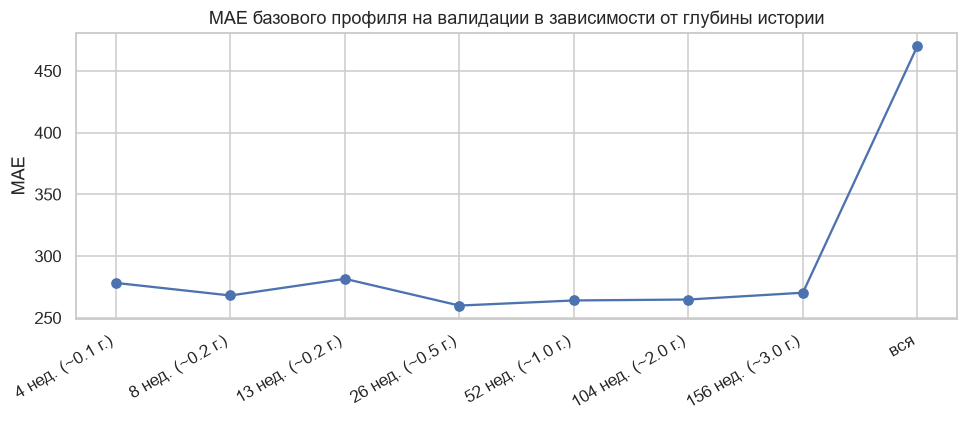

Выбранная глубина истории: 26 недель (4368 часов)


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(window_res)), window_res["MAE"], marker="o")
ax.set_xticks(range(len(window_res)))
ax.set_xticklabels(window_res.index, rotation=30, ha="right")
ax.set_title("MAE базового профиля на валидации в зависимости от глубины истории")
ax.set_ylabel("MAE")
plt.tight_layout(); plt.show()

best_window = window_res["MAE"].idxmin()
TRAIN_WEEKS = None if best_window == "вся" else int(best_window.split()[0])
TRAIN_LEN = None if TRAIN_WEEKS is None else TRAIN_WEEKS * WEEK
print("Выбранная глубина истории:", "вся" if TRAIN_WEEKS is None else f"{TRAIN_WEEKS} недель ({TRAIN_LEN} часов)")

Ограниченная свежая история работает лучше полной: старые годы (в том числе искусственно «достроенные»
интерполяцией участки) только зашумляют оценку сезонного профиля. Дальше все модели обучаем на выбранном окне.

In [22]:
def trim(history):
    # Обрезаем историю до выбранного окна обучения.
    return history if TRAIN_LEN is None else history.iloc[-TRAIN_LEN:]

## 4. Baseline: средние по дню недели и часу

Считаем `groupby(["weekday", "hour"])["traffic_volume"].mean()`
и используем эти значения как прогноз на отложенную выборку.

In [23]:
def fn_baseline(history, horizon, future):
    return profile_forecast(history, horizon, future, weeks=TRAIN_WEEKS)


pred_val, pred_test = {}, {}
BASE = "Baseline (weekday×hour)"
pred_val[BASE] = rolling_forecast(fn_baseline, val_index)
pred_test[BASE] = rolling_forecast(fn_baseline, test_index)

print("Baseline на валидации:", {k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[BASE]).items()})
print("Baseline на тесте:    ", {k: round(v, 2) for k, v in metrics(y.loc[test_index], pred_test[BASE]).items()})

Baseline на валидации: {'MAE': np.float64(259.9), 'RMSE': np.float64(531.61), 'MAPE, %': np.float64(12.37), 'sMAPE, %': np.float64(9.74), 'R2': np.float64(0.93)}
Baseline на тесте:     {'MAE': np.float64(202.01), 'RMSE': np.float64(298.69), 'MAPE, %': np.float64(8.11), 'sMAPE, %': np.float64(8.04), 'R2': np.float64(0.98)}


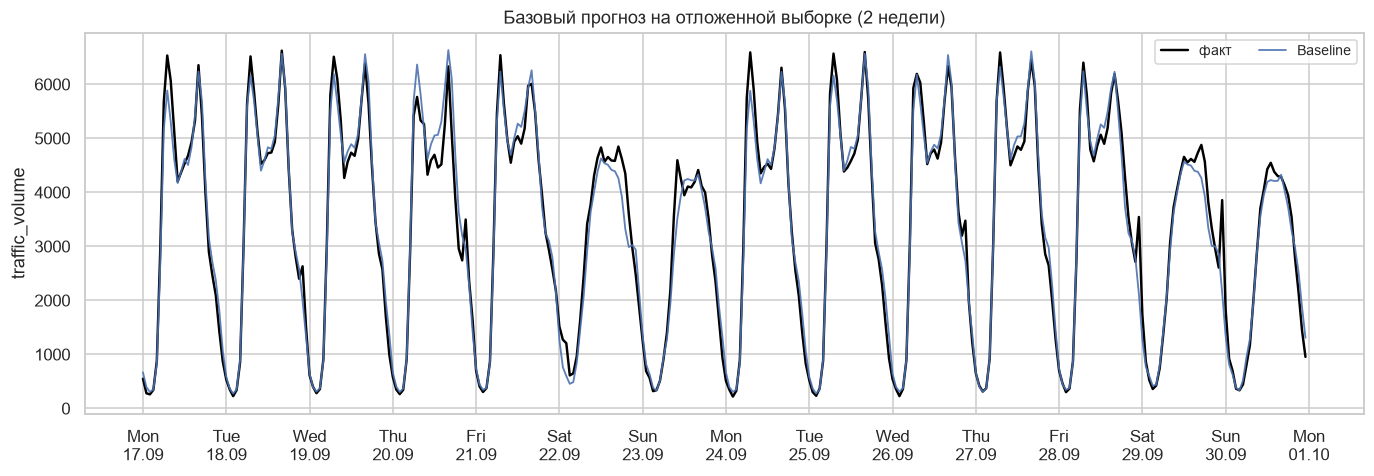

In [24]:
def plot_forecast(true, preds, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.plot(true.index, true.values, color="black", lw=1.6, label="факт")
    for name, p in preds.items():
        ax.plot(p.index, p.values, lw=1.2, alpha=0.9, label=name)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d.%m"))
    ax.set_title(title)
    ax.set_ylabel("traffic_volume")
    ax.legend(ncol=3, fontsize=9)
    return ax


plot_forecast(y.loc[test_index], {"Baseline": pred_test[BASE]},
              "Базовый прогноз на отложенной выборке (2 недели)")
plt.show()

## 5. Модели

### 5.1. Сезонное наивное предсказание

Прогноз = значение неделю назад. Ориентир для рядов с недельной сезонностью.

In [25]:
def fn_snaive(history, horizon, future):
    last_week = history.iloc[-WEEK:].values
    return np.resize(last_week, horizon)


NAME = "Seasonal naive (лаг 168)"
pred_val[NAME] = rolling_forecast(fn_snaive, val_index)
pred_test[NAME] = rolling_forecast(fn_snaive, test_index)
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[NAME]).items()})

{'MAE': np.float64(373.07), 'RMSE': np.float64(795.54), 'MAPE, %': np.float64(16.23), 'sMAPE, %': np.float64(13.81), 'R2': np.float64(0.83)}


### 5.2. Хольт-Уинтерс (тройное экспоненциальное сглаживание)

Аддитивная модель с недельной сезонностью (168 точек). Суточная сезонность при этом «зашита»
внутрь недельного цикла, поэтому отдельный суточный период задавать не нужно.

In [26]:
def fn_holt_winters(history, horizon, future):
    h = trim(history)
    model = ExponentialSmoothing(
        h, trend="add", damped_trend=True, seasonal="add",
        seasonal_periods=WEEK, initialization_method="estimated",
    ).fit()
    return model.forecast(horizon).values


NAME = "Holt-Winters (168)"
t0 = time.time()
pred_val[NAME] = rolling_forecast(fn_holt_winters, val_index)
pred_test[NAME] = rolling_forecast(fn_holt_winters, test_index)
print(f"обучение заняло {time.time() - t0:.1f} c")
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[NAME]).items()})

обучение заняло 2.1 c
{'MAE': np.float64(410.97), 'RMSE': np.float64(645.64), 'MAPE, %': np.float64(25.05), 'sMAPE, %': np.float64(25.02), 'R2': np.float64(0.89)}


### 5.3. Прогноз температуры

Температуру используем как признак. Но на горизонте прогноза её значения
неизвестны, поэтому температуру нужно прогнозировать отдельно. Строим для неё SARIMA с суточной
сезонностью (через гармоники Фурье) и кэшируем прогнозы, чтобы не переобучать модель для каждой
модели трафика.

обучение заняло 4.1 c
Прогноз температуры на тесте: {'MAE': np.float64(8.89), 'RMSE': np.float64(9.96), 'MAPE, %': np.float64(14.37), 'sMAPE, %': np.float64(13.17), 'R2': np.float64(-3.02)}


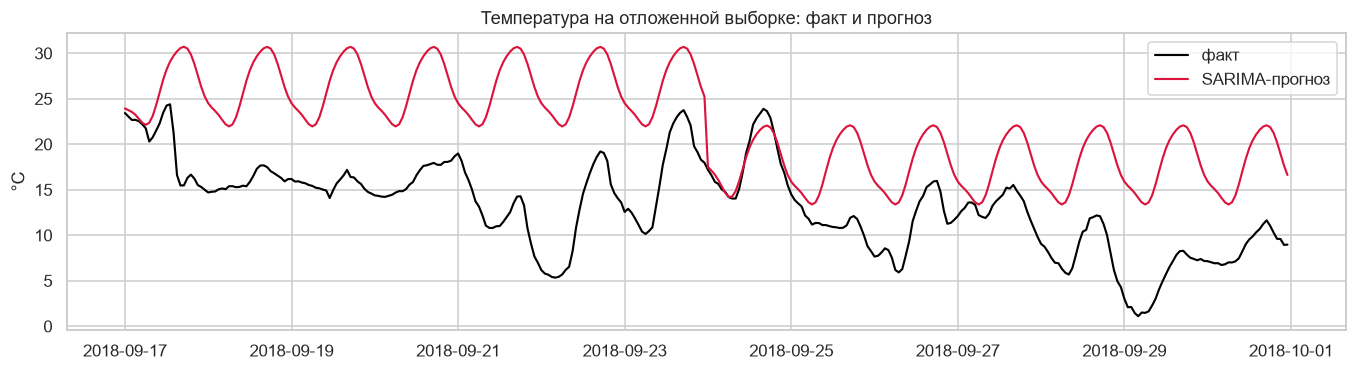

In [27]:
ORIGIN = data.index[0]


def fourier_terms(index, period, K):
    t = (index - ORIGIN) / pd.Timedelta("1h")
    out = {}
    for k in range(1, K + 1):
        out[f"sin_{period}_{k}"] = np.sin(2 * np.pi * k * t / period)
        out[f"cos_{period}_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(out, index=index)


temp_series = data["temp_c"]
_TEMP_CACHE = {}


def temp_forecast(future):
    # SARIMA-прогноз температуры на индекс `future` по истории строго до его начала.
    key = future[0]
    if key not in _TEMP_CACHE:
        hist = temp_series.loc[:key - pd.Timedelta("1h")].iloc[-26 * WEEK:]
        X_tr = fourier_terms(hist.index, DAY, 3)
        X_fu = fourier_terms(future, DAY, 3)
        m = SARIMAX(hist, exog=X_tr, order=(2, 1, 2),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        _TEMP_CACHE[key] = pd.Series(m.forecast(len(future), exog=X_fu).values, index=future)
    return _TEMP_CACHE[key]


def temp_known(future):
    # Температура: факт в прошлом + прогноз на горизонте.
    return pd.concat([temp_series.loc[:future[0] - pd.Timedelta("1h")], temp_forecast(future)])


t0 = time.time()
temp_pred_test = pd.concat([temp_forecast(test_index[:HORIZON]), temp_forecast(test_index[HORIZON:])])
print(f"обучение заняло {time.time() - t0:.1f} c")
print("Прогноз температуры на тесте:",
      {k: round(v, 2) for k, v in metrics(temp_series.loc[test_index] + 50, temp_pred_test + 50).items()})

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(test_index, temp_series.loc[test_index], color="black", lw=1.4, label="факт")
ax.plot(temp_pred_test.index, temp_pred_test.values, color="crimson", lw=1.4, label="SARIMA-прогноз")
ax.set_title("Температура на отложенной выборке: факт и прогноз")
ax.set_ylabel("°C"); ax.legend()
plt.show()

### 5.4. SARIMAX с недельной сезонностью и экзогенными признаками

Задание рекомендует сезонность 24×7, но прямое `seasonal_order=(P, D, Q, 168)` в `statsmodels`
вычислительно неподъёмно: размерность вектора состояния растёт до сотен, и одна оценка модели
на нашем ряде не заканчивается за десятки минут.

Недельную сезонность передаём модели **напрямую — профилем «день недели × час» в виде
экзогенного регрессора** (те самые 168 параметров, что и у baseline), а SARIMA(2,0,1)(1,0,1,24)
моделирует остаток: суточную динамику и локальные отклонения уровня. Во второй версии добавляем
в экзогенные признаки праздники и прогноз температуры.

In [28]:
def sarimax_exog(index, history, temp=None):
    # недельная сезонность 24x7 как экзогенный регрессор + (опционально) праздники и температура
    prof = history.groupby([history.index.weekday, history.index.hour]).mean()
    X = pd.DataFrame(index=index)
    X["profile"] = prof.reindex(pd.MultiIndex.from_arrays([index.weekday, index.hour])).values
    if temp is not None:
        X["is_holiday"] = holiday_flag(index)
        X["temp_c"] = temp.reindex(index).values
    return X


def make_sarimax_fn(use_extra_exog=True):
    def fn(history, horizon, future):
        h = trim(history)
        temp = temp_known(future) if use_extra_exog else None
        X_tr, X_fu = sarimax_exog(h.index, h, temp), sarimax_exog(future, h, temp)
        res = SARIMAX(h, exog=X_tr, order=(2, 0, 1), seasonal_order=(1, 0, 1, DAY), trend="c",
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        return res.forecast(horizon, exog=X_fu).values
    return fn


fn_sarimax_plain = make_sarimax_fn(use_extra_exog=False)
NAME = "SARIMAX (профиль 24×7)"
t0 = time.time()
pred_val[NAME] = rolling_forecast(fn_sarimax_plain, val_index)
pred_test[NAME] = rolling_forecast(fn_sarimax_plain, test_index)
print(f"обучение заняло {time.time() - t0:.1f} c")
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[NAME]).items()})

обучение заняло 21.0 c
{'MAE': np.float64(262.05), 'RMSE': np.float64(542.14), 'MAPE, %': np.float64(12.7), 'sMAPE, %': np.float64(9.97), 'R2': np.float64(0.92)}


In [29]:
fn_sarimax_exog = make_sarimax_fn(use_extra_exog=True)
NAME = "SARIMAX + температура и праздники"
t0 = time.time()
pred_val[NAME] = rolling_forecast(fn_sarimax_exog, val_index)
pred_test[NAME] = rolling_forecast(fn_sarimax_exog, test_index)
print(f"обучение заняло {time.time() - t0:.1f} c")
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[NAME]).items()})

обучение заняло 42.7 c
{'MAE': np.float64(259.0), 'RMSE': np.float64(452.34), 'MAPE, %': np.float64(14.34), 'sMAPE, %': np.float64(13.2), 'R2': np.float64(0.95)}


                                     SARIMAX Results                                      
Dep. Variable:                     traffic_volume   No. Observations:                 4368
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -29725.860
Date:                            Mon, 31 Aug 2026   AIC                          59471.720
Time:                                    21:30:10   BIC                          59535.481
Sample:                                03-05-2018   HQIC                         59494.227
                                     - 09-02-2018                                         
Covariance Type:                              opg                                         


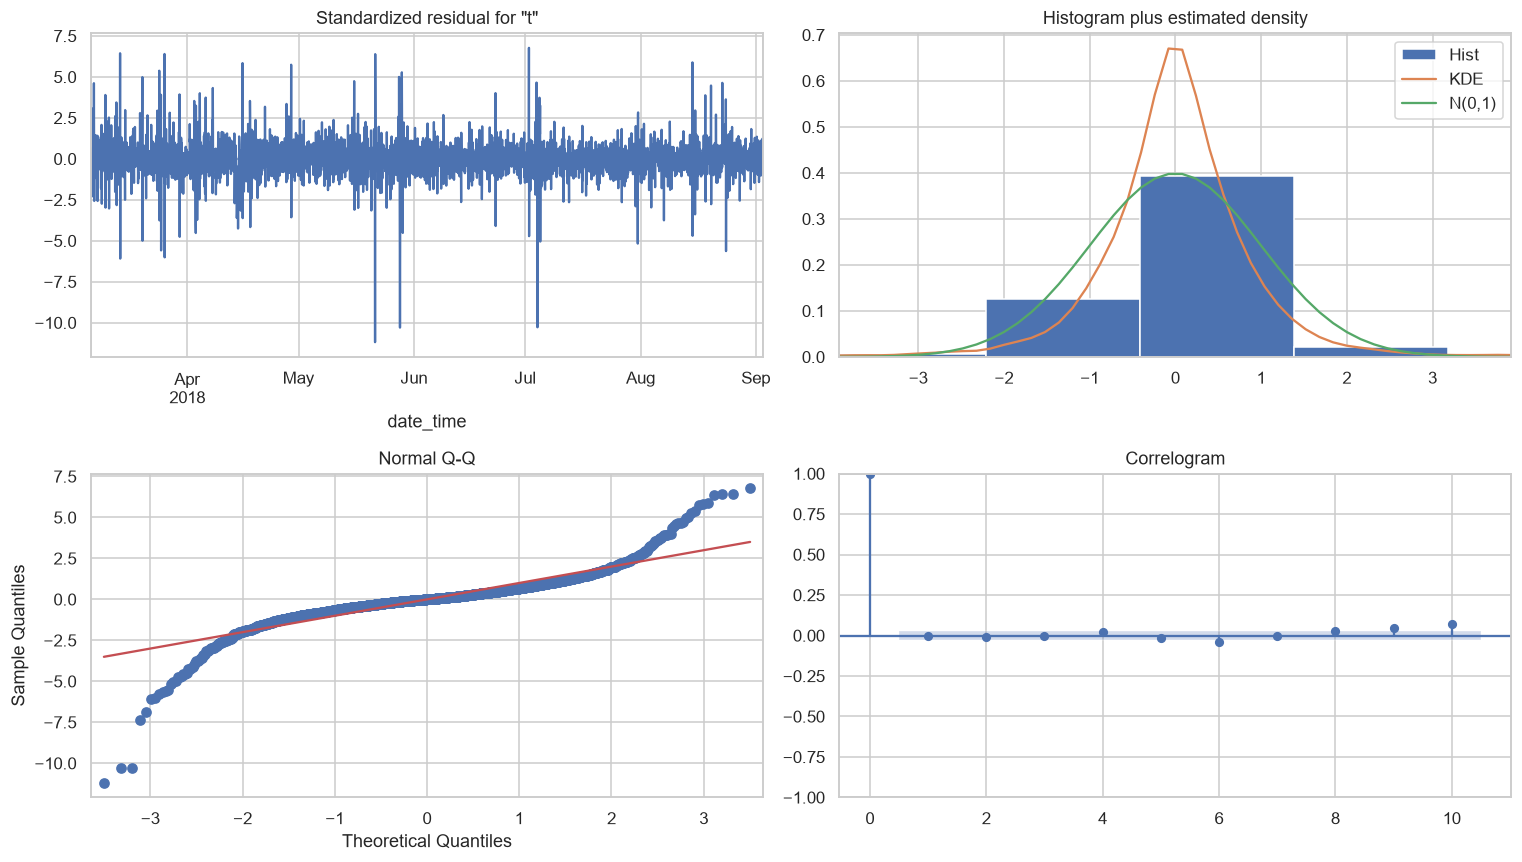

In [30]:
h_diag = trim(y.loc[:val_index[0] - pd.Timedelta("1h")])
temp_diag = temp_known(val_index)
res_diag = SARIMAX(h_diag, exog=sarimax_exog(h_diag.index, h_diag, temp_diag), order=(2, 0, 1),
                   seasonal_order=(1, 0, 1, DAY), trend="c", enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False, maxiter=100)
print(res_diag.summary().tables[0])
fig = res_diag.plot_diagnostics(figsize=(14, 8))
plt.tight_layout(); plt.show()

### 5.5. Ridge-регрессия на календарных признаках


In [31]:
def ridge_design(index, temp):
    hw = index.weekday * 24 + index.hour              # 168 «слотов» недели
    D = np.eye(168, dtype=float)[hw]
    t = temp.reindex(index).values
    extra = np.column_stack([t, holiday_flag(index)])
    return np.hstack([D, extra])


def fn_ridge(history, horizon, future):
    h = trim(history)
    temp = temp_known(future)
    model = Ridge(alpha=1.0, fit_intercept=True)
    model.fit(ridge_design(h.index, temp), h.values)
    return model.predict(ridge_design(future, temp))


NAME = "Ridge (календарь + температура)"
pred_val[NAME] = rolling_forecast(fn_ridge, val_index)
pred_test[NAME] = rolling_forecast(fn_ridge, test_index)
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[NAME]).items()})

{'MAE': np.float64(277.73), 'RMSE': np.float64(447.5), 'MAPE, %': np.float64(19.26), 'sMAPE, %': np.float64(16.89), 'R2': np.float64(0.95)}


### 5.6. Градиентный бустинг (LightGBM)

Нелинейная модель на календарных, погодных и лаговых признаках. Лаги — только «безопасные»
(≥ 336 часов), поэтому прогноз строится сразу на весь горизонт, без рекурсии и без утечек.

In [32]:
LGB_FEATURES = ["hour", "weekday", "month", "dayofyear", "is_weekend",
                "sin_hour", "cos_hour", "sin_wday", "cos_wday",
                "is_holiday", "temp_c"] + [f"lag_{l}" for l in LAGS] + ["lag_mean"]


def build_features(index, history, temp):
    X = calendar_features(index)
    X["is_holiday"] = holiday_flag(index)
    X["temp_c"] = temp.reindex(index).values
    for lag in LAGS:
        X[f"lag_{lag}"] = history.reindex(index - pd.Timedelta(hours=lag)).values
    X["lag_mean"] = X[[f"lag_{l}" for l in LAGS]].mean(axis=1)
    return X[LGB_FEATURES]


def fn_lgbm(history, horizon, future):
    h = trim(history)
    temp = temp_known(future)
    X_tr = build_features(h.index, history, temp)
    ok = X_tr.notna().all(axis=1).values
    model = lgb.LGBMRegressor(
        n_estimators=600, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.9, subsample_freq=1,
        colsample_bytree=0.9, random_state=RANDOM_STATE, verbose=-1,
    )
    model.fit(X_tr[ok], h.values[ok], categorical_feature=["hour", "weekday", "month"])
    fn_lgbm.last_model = model
    fn_lgbm.last_features = list(X_tr.columns)
    return model.predict(build_features(future, history, temp))


NAME = "LightGBM"
t0 = time.time()
pred_val[NAME] = rolling_forecast(fn_lgbm, val_index)
pred_test[NAME] = rolling_forecast(fn_lgbm, test_index)
print(f"обучение заняло {time.time() - t0:.1f} c")
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[NAME]).items()})

обучение заняло 2.7 c
{'MAE': np.float64(213.92), 'RMSE': np.float64(344.34), 'MAPE, %': np.float64(9.9), 'sMAPE, %': np.float64(9.04), 'R2': np.float64(0.97)}


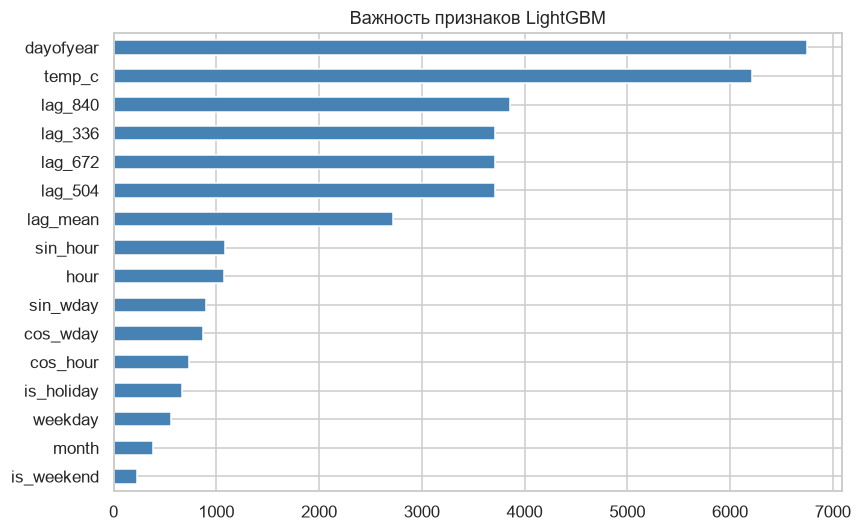

In [33]:
imp = pd.Series(fn_lgbm.last_model.feature_importances_, index=fn_lgbm.last_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color="steelblue")
ax.set_title("Важность признаков LightGBM")
plt.tight_layout(); plt.show()

### 5.7. Ансамбль

Усреднение лучших по валидации моделей может дать ещё небольшой выигрыш за счёт
компенсации разнонаправленных ошибок.

In [34]:
val_table = pd.DataFrame({name: metrics(y.loc[val_index], p) for name, p in pred_val.items()}).T
best_two = val_table.sort_values("MAE").index[:2].tolist()
print("Две лучшие модели на валидации:", best_two)

ENS = "Ансамбль (среднее топ-2)"
pred_val[ENS] = sum(pred_val[n] for n in best_two) / 2
pred_test[ENS] = sum(pred_test[n] for n in best_two) / 2
print({k: round(v, 2) for k, v in metrics(y.loc[val_index], pred_val[ENS]).items()})

Две лучшие модели на валидации: ['LightGBM', 'SARIMAX + температура и праздники']
{'MAE': np.float64(215.53), 'RMSE': np.float64(375.18), 'MAPE, %': np.float64(10.51), 'sMAPE, %': np.float64(10.08), 'R2': np.float64(0.96)}


### 5.8. Сравнение моделей

In [35]:
val_table = pd.DataFrame({name: metrics(y.loc[val_index], p) for name, p in pred_val.items()}).T
val_table.sort_values("MAE").round(2)

,MAE,RMSE,"MAPE, %","sMAPE, %",R2
LightGBM,213.92,344.34,9.90,9.04,0.97
Ансамбль (среднее топ-2),215.53,375.18,10.51,10.08,0.96
SARIMAX + температура и праздники,259.00,452.34,14.34,13.20,0.95
Baseline (weekday×hour),259.90,531.61,12.37,9.74,0.93
SARIMAX (профиль 24×7),262.05,542.14,12.70,9.97,0.92
Ridge (календарь + температура),277.73,447.50,19.26,16.89,0.95
Seasonal naive (лаг 168),373.07,795.54,16.23,13.81,0.83
Holt-Winters (168),410.97,645.64,25.05,25.02,0.89


In [36]:
test_table = pd.DataFrame({name: metrics(y.loc[test_index], p) for name, p in pred_test.items()}).T
test_table = test_table.sort_values("MAE")
base_mae = test_table.loc[BASE, "MAE"]
test_table["выигрыш к baseline, %"] = (1 - test_table["MAE"] / base_mae) * 100
test_table.round(2)

,MAE,RMSE,"MAPE, %","sMAPE, %",R2,"выигрыш к baseline, %"
Ансамбль (среднее топ-2),172.74,270.34,7.53,7.45,0.98,14.49
LightGBM,177.74,275.05,8.21,8.08,0.98,12.01
Baseline (weekday×hour),202.01,298.69,8.11,8.04,0.98,0.00
SARIMAX (профиль 24×7),202.04,299.59,8.09,8.30,0.98,-0.01
Seasonal naive (лаг 168),205.86,333.91,9.25,8.74,0.97,-1.91
SARIMAX + температура и праздники,207.76,299.66,8.98,8.84,0.98,-2.85
Ridge (календарь + температура),234.56,313.88,15.23,13.08,0.97,-16.11
Holt-Winters (168),325.62,435.99,15.97,19.74,0.95,-61.19


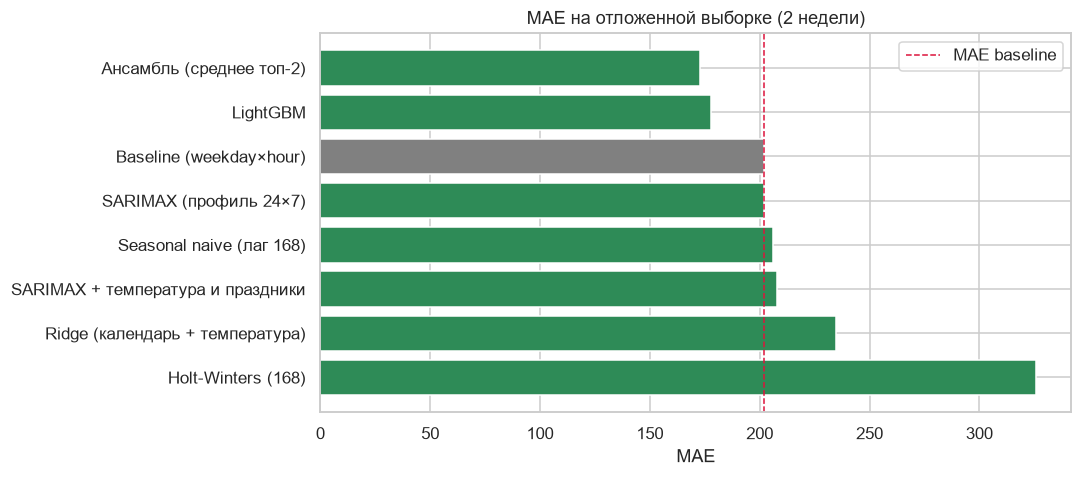

In [37]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = test_table.sort_values("MAE").index
colors = ["grey" if n == BASE else "seagreen" for n in order]
ax.barh(range(len(order)), test_table.loc[order, "MAE"], color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.invert_yaxis()
ax.axvline(base_mae, color="crimson", ls="--", lw=1, label="MAE baseline")
ax.set_title("MAE на отложенной выборке (2 недели)")
ax.set_xlabel("MAE"); ax.legend()
plt.tight_layout(); plt.show()

Лучшая модель на отложенной выборке: Ансамбль (среднее топ-2)


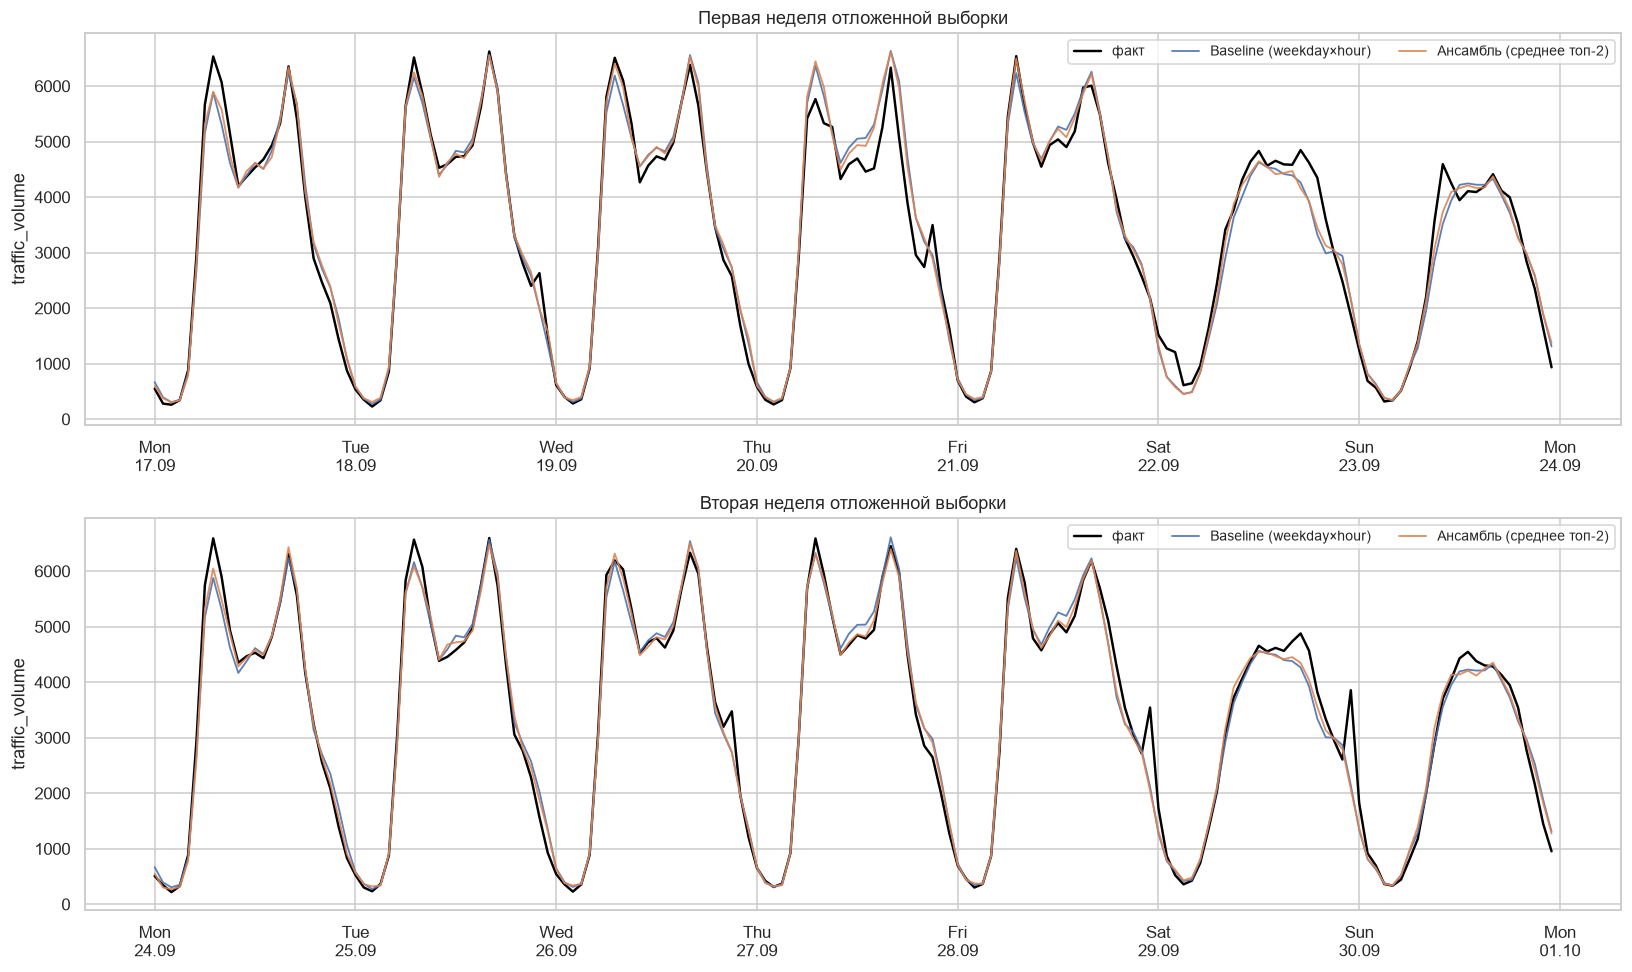

In [38]:
BEST = test_table.index[0]
print("Лучшая модель на отложенной выборке:", BEST)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharey=True)
show = [BASE] + ([BEST] if BEST != BASE else [])
plot_forecast(y.loc[test_index[:HORIZON]], {n: pred_test[n].iloc[:HORIZON] for n in show},
              "Первая неделя отложенной выборки", ax=axes[0])
plot_forecast(y.loc[test_index[HORIZON:]], {n: pred_test[n].iloc[HORIZON:] for n in show},
              "Вторая неделя отложенной выборки", ax=axes[1])
plt.tight_layout(); plt.show()

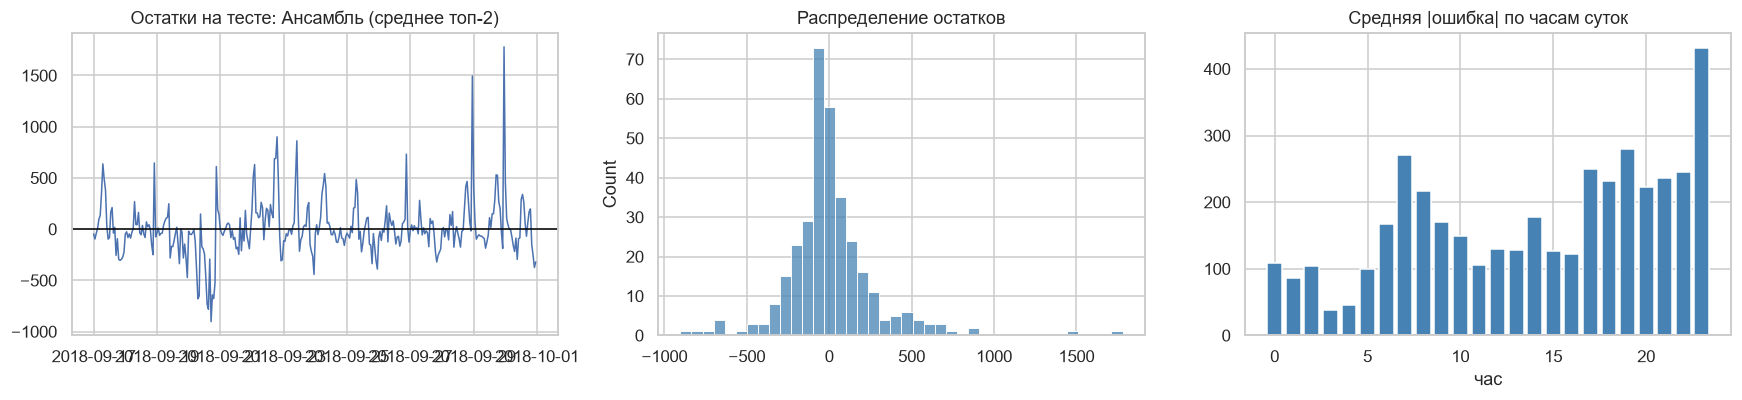

Смещение прогноза (средний остаток): 6.3


In [39]:
resid = y.loc[test_index] - pred_test[BEST]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
axes[0].plot(resid.index, resid.values, lw=1); axes[0].axhline(0, color="black", lw=1)
axes[0].set_title(f"Остатки на тесте: {BEST}")
sns.histplot(resid, bins=40, ax=axes[1], color="steelblue"); axes[1].set_title("Распределение остатков")
by_hour = resid.abs().groupby(resid.index.hour).mean()
axes[2].bar(by_hour.index, by_hour.values, color="steelblue")
axes[2].set_title("Средняя |ошибка| по часам суток"); axes[2].set_xlabel("час")
plt.tight_layout(); plt.show()
print("Смещение прогноза (средний остаток):", round(resid.mean(), 1))

## 6. Финальный прогноз на неделю вперёд с доверительными интервалами

Модель, выбранная по качеству, переобучается на **всех** данных (включая отложенную выборку)
и прогнозирует следующие 24 × 7 = 168 часов.

Доверительные интервалы строим двумя способами:

* **аналитический** — из SARIMAX (`get_forecast().conf_int()`), опирается на предпосылки модели;
* **эмпирический** — по квантилям ошибок выбранной модели на валидации и тесте (в разрезе часов суток).
  Он честнее отражает реальную точность именно нашей схемы прогнозирования.

In [40]:
future_index = pd.date_range(y.index[-1] + pd.Timedelta("1h"), periods=HORIZON, freq="h")
print("Прогнозируем период:", future_index[0], "—", future_index[-1])

MODEL_FNS = {
    BASE: fn_baseline,
    "Seasonal naive (лаг 168)": fn_snaive,
    "Holt-Winters (168)": fn_holt_winters,
    "SARIMAX (профиль 24×7)": fn_sarimax_plain,
    "SARIMAX + температура и праздники": fn_sarimax_exog,
    "Ridge (календарь + температура)": fn_ridge,
    "LightGBM": fn_lgbm,
}

if BEST == ENS:
    final_pred = sum(pd.Series(MODEL_FNS[n](y, HORIZON, future_index), index=future_index)
                     for n in best_two) / 2
else:
    final_pred = pd.Series(MODEL_FNS[BEST](y, HORIZON, future_index), index=future_index)

final_pred = final_pred.clip(lower=0)
final_pred.head()

Прогнозируем период: 2018-10-01 00:00:00 — 2018-10-07 23:00:00


2018-10-01 00:00:00    422.734317
2018-10-01 01:00:00    181.569033
2018-10-01 02:00:00     92.004206
2018-10-01 03:00:00    182.025718
2018-10-01 04:00:00    673.779573
Freq: h, dtype: float64

In [41]:
# эмпирические интервалы: квантили ошибок выбранной модели вне обучения (валидация + тест)
oos_resid = pd.concat([
    y.loc[val_index] - pred_val[BEST],
    y.loc[test_index] - pred_test[BEST],
])
q = oos_resid.groupby(oos_resid.index.hour).quantile([0.05, 0.95]).unstack()
lo_emp = (final_pred + q[0.05].reindex(final_pred.index.hour).values).clip(lower=0)
hi_emp = final_pred + q[0.95].reindex(final_pred.index.hour).values

print("Средняя ширина 90% эмпирического интервала:", round((hi_emp - lo_emp).mean()), "авто/час")

Средняя ширина 90% эмпирического интервала: 754 авто/час


In [42]:
# аналитический интервал из SARIMAX, обученной на всех данных
h_all = trim(y)
temp_all = temp_known(future_index)
res_final = SARIMAX(h_all, exog=sarimax_exog(h_all.index, h_all, temp_all), order=(2, 0, 1),
                    seasonal_order=(1, 0, 1, DAY), trend="c", enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False, maxiter=100)
fc = res_final.get_forecast(HORIZON, exog=sarimax_exog(future_index, h_all, temp_all))
ci = fc.conf_int(alpha=0.10)
ci.columns = ["lo", "hi"]

print("Средняя ширина 90% аналитического интервала SARIMAX:", round((ci["hi"] - ci["lo"]).mean()), "авто/час")

Средняя ширина 90% аналитического интервала SARIMAX: 1257 авто/час


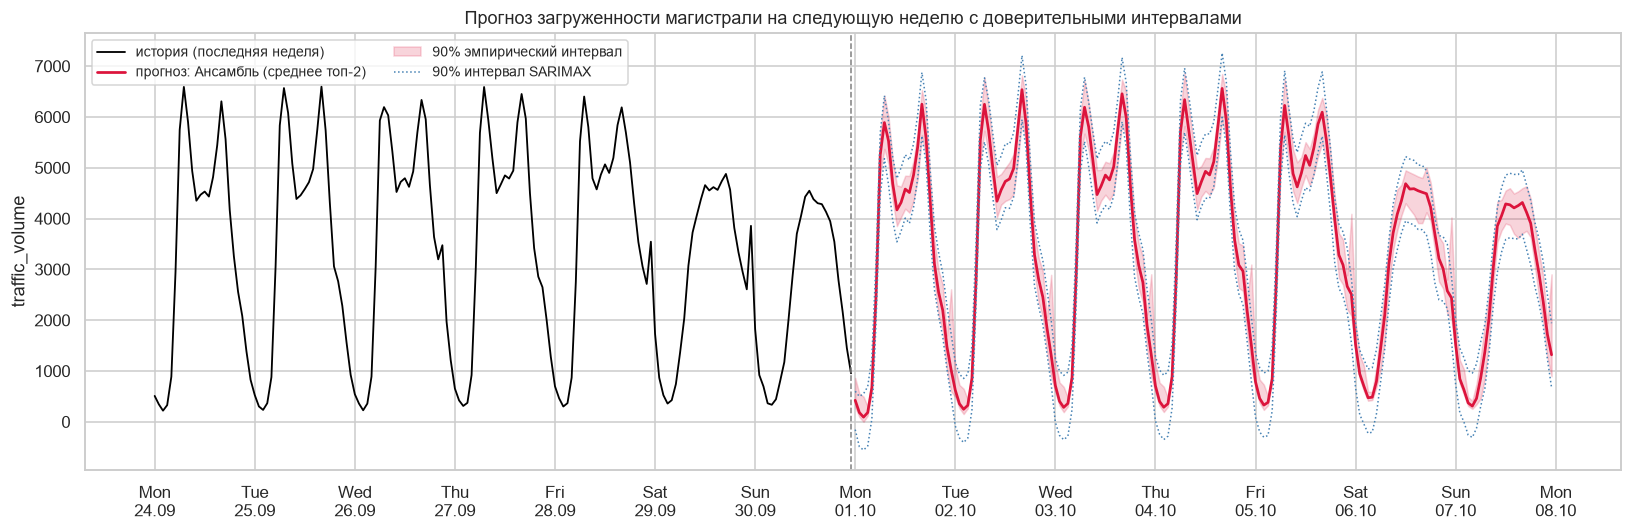

In [43]:
fig, ax = plt.subplots(figsize=(15, 5))
hist_tail = y.iloc[-WEEK:]
ax.plot(hist_tail.index, hist_tail.values, color="black", lw=1.2, label="история (последняя неделя)")
ax.plot(final_pred.index, final_pred.values, color="crimson", lw=1.8, label=f"прогноз: {BEST}")
ax.fill_between(final_pred.index, lo_emp, hi_emp, color="crimson", alpha=0.18,
                label="90% эмпирический интервал")
ax.plot(ci.index, ci["lo"], color="steelblue", ls=":", lw=1)
ax.plot(ci.index, ci["hi"], color="steelblue", ls=":", lw=1, label="90% интервал SARIMAX")
ax.axvline(y.index[-1], color="grey", ls="--", lw=1)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d.%m"))
ax.set_title("Прогноз загруженности магистрали на следующую неделю с доверительными интервалами")
ax.set_ylabel("traffic_volume"); ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

In [44]:
forecast_df = pd.DataFrame({
    "прогноз": final_pred.round(0),
    "нижняя граница (90%)": np.round(lo_emp, 0),
    "верхняя граница (90%)": np.round(hi_emp, 0),
})
forecast_df.index.name = "час"
print("Суммарный прогнозируемый трафик за неделю:", int(final_pred.sum()))
print("Пиковый час:", final_pred.idxmax(), "→", int(final_pred.max()), "авто/час")
forecast_df.head(24)

Суммарный прогнозируемый трафик за неделю: 562905
Пиковый час: 2018-10-04 16:00:00 → 6560 авто/час


,прогноз,нижняя граница (90%),верхняя граница (90%)
час,,,
2018-10-01 00:00:00,423.0,286.0,863.0
2018-10-01 01:00:00,182.0,96.0,552.0
2018-10-01 02:00:00,92.0,0.0,496.0
2018-10-01 03:00:00,182.0,122.0,297.0
2018-10-01 04:00:00,674.0,619.0,779.0
2018-10-01 05:00:00,2493.0,2377.0,2778.0
2018-10-01 06:00:00,5253.0,4849.0,5656.0
2018-10-01 07:00:00,5889.0,5371.0,6419.0
2018-10-01 08:00:00,5525.0,5069.0,5998.0


## 7. Выводы

**Данные.** Исходный ряд был «грязным»: 7 629 дубликатов по времени , неравномерная сетка,
несколько крупных разрывов вплоть до нескольких месяцев и аномалии `temp = 0 K`.

**Структура ряда.** Тренда практически нет, зато очень сильные суточная (два пика буднего дня) и
недельная (провал в выходные) сезонности. Праздники снижают трафик, температура связана с ним слабо,
но положительно.

**Глубина истории.** Проверка на валидации показала, что брать все 6 лет вредно: лучший результат даёт
ограниченное свежее окно. Старые годы содержат интерполированные разрывы и устаревший режим трафика.

**Модели.** Baseline «среднее по (день недели, час)» — сильный ориентир: сезонность
объясняет большую часть дисперсии, и большинство классических моделей его не превосходят.
SARIMAX с профилем 24×7 выходит примерно на уровень baseline, а Ridge проигрывает
из-за ошибки прогноза температуры. Уверенно обыгрывает baseline **LightGBM** на лаговых и календарных
признаках (−12% MAE на отложенной выборке), а лучший результат даёт **ансамбль** из LightGBM и SARIMAX
(−14.5% MAE).